# Loading Data Set and Importing Libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [5]:
path=r"C:\Users\piyus\Desktop\Desk Top\02-04-2026 Mess to sort out\Project 02 European Bank\European_Bank.csv"
df=pd.read_csv(path)
print("Loaded Dataset sucessfully!")

Loaded Dataset sucessfully!


# Segment-wise churn rates

## 0. Geography Wise Churn Rate:

In [ ]:
# klkl Variable is to filter Region.
klkl=input("Enter a your Region")

gb=df[df["Geography"]==klkl]

gb[gb["Exited"]== 1].shape[0],gb[gb["Exited"]== 0].shape[0]

labels = ("Customers", "Ex-Customers")
values = (gb[gb["Exited"] == 1].shape[0],   # ✅ not churned
          gb[gb["Exited"] == 0].shape[0])    # ✅ churned



def autopct_func(pct):
    total = sum(values)
    absolute = int(round(pct * total / 100.0))   # or just int(pct * total / 100)
    return f'{pct:.1f}%\n({absolute})'
    
plt.pie(values, labels=labels, autopct=autopct_func, startangle=90)
plt.title("Churn Distribution")
plt.show()

#### Churn distribution along 
<ul>Spain     16.7% (413)     83.3% (2064)</ul>
<ul>Germany   32.4% (814)     67.6%  (1659)</ul>
<ul>France    16.2% (810)     83.83% (4204)</ul>


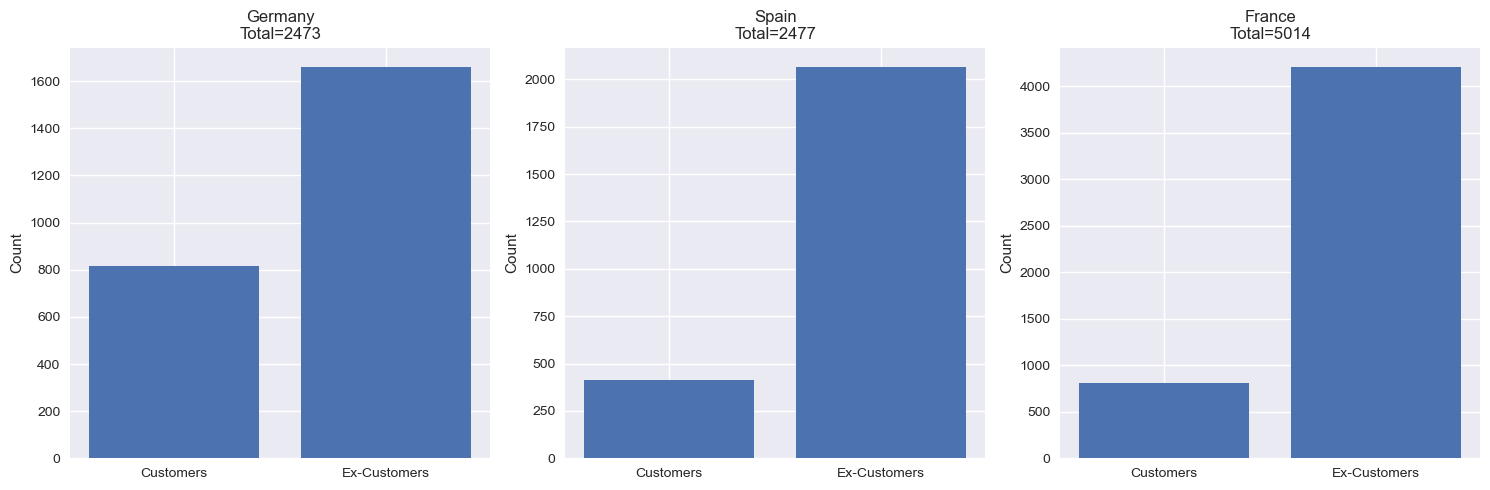

In [7]:
import matplotlib.pyplot as plt
import numpy as np



Customers = [413, 814, 810]
Ex_Customers = [2064, 1659, 4204]
Region = ["Spain", "Germany", "France"]

# Total
Total = [c + e for c, e in zip(Customers, Ex_Customers)]

# Sort by total (ascending)
sorted_data = sorted(zip(Total, Region, Customers, Ex_Customers))

# Unpack sorted values
Total_s, Region_s, Customers_s, Ex_Customers_s = zip(*sorted_data)

# Subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(3):
    axes[i].bar(['Customers', 'Ex-Customers'],
                [Customers_s[i], Ex_Customers_s[i]])
    
    axes[i].set_title(f"{Region_s[i]}\nTotal={Total_s[i]}")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

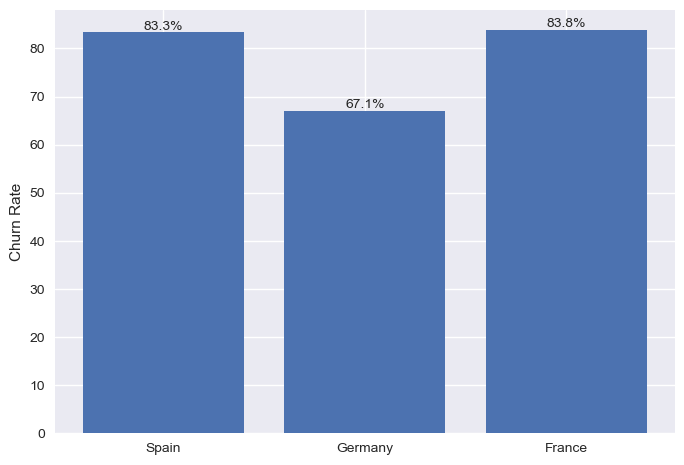

In [8]:
# Chart for churn Rate
churn_rate = [c/t*100 for c, t in zip(Ex_Customers, Total)]

bars = plt.bar(Region, churn_rate)
for bar, val in zip(bars, churn_rate):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.1f}%', ha='center', va='bottom')
plt.ylabel("Churn Rate")
plt.show()


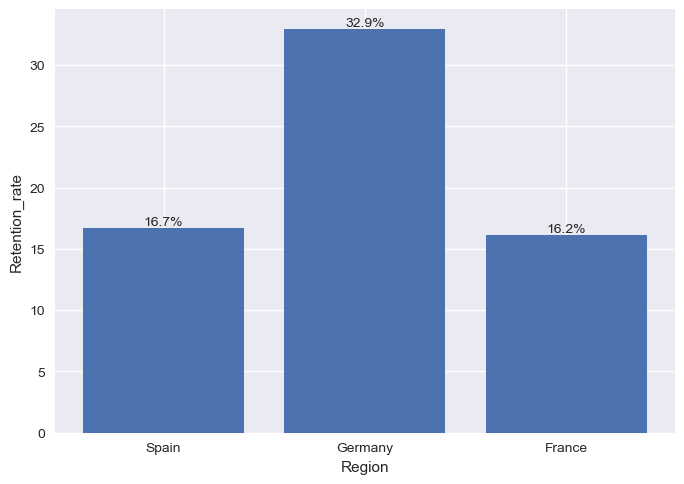

In [9]:
# Chart for Retention_rate
Retention_rate = [c/t*100 for c, t in zip(Customers, Total)]

bars = plt.bar(Region, Retention_rate)
for bar, val in zip(bars, Retention_rate):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.1f}%', ha='center', va='bottom')
plt.ylabel("Retention_rate")
plt.xlabel("Region")
plt.show()

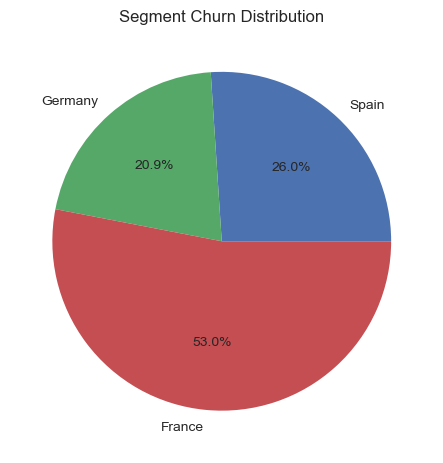

In [10]:
# Segment-wise analysis in Region Category 

import matplotlib.pyplot as plt

labels = Region 
sizes = Ex_Customers

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Segment Churn Distribution')

plt.show()

#### France has the Largest Churn of 53.0

# 1. Balance Range

In [30]:
# Segments
Zero_B=df[df["Balance"]==0]
Medium_B=df[(df["Balance"]>0)&(df["Balance"]<=127644)]
High_B=df[df["Balance"]>127644]

In [31]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('ggplot')

# Zero Balance Variable
C_Zero=Zero_B[Zero_B["Exited"]==1]
Cex_Zero=Zero_B[Zero_B["Exited"]==0]

C_Medium=Medium_B[Medium_B["Exited"]==1]
Cex_Medium=Medium_B[Medium_B["Exited"]==0]

C_High=High_B[High_B["Exited"]==1]
Cex_High=High_B[High_B["Exited"]==0]



Customers_b = [C_Zero.shape[0], C_Medium.shape[0], C_High.shape[0]]
Ex_Customers_b = [Cex_Zero.shape[0], Cex_Medium.shape[0], Cex_High.shape[0]]
Balance = ["Zero Balance", "Medium Balance", "High Balance"]
Total_b=[ C_Zero.shape[0]+Cex_Zero.shape[0],C_Medium.shape[0]+Cex_Medium.shape[0],C_High.shape[0]+Cex_High.shape[0]]
# Total
Total = [c + e for c, e in zip(Customers, Ex_Customers)]

# # Sort by total (ascending)
# sorted_data = sorted(zip(Total, Region, Customers, Ex_Customers))

# # Unpack sorted values
# Total_s, Region_s, Customers_s, Ex_Customers_s = zip(*sorted_data)

# # Subplots
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# for i in range(3):
#     axes[i].bar(['Customers', 'Ex-Customers'],
#                 [Customers_s[i], Ex_Customers_s[i]])
    
#     axes[i].set_title(f"{Region_s[i]}\nTotal={Total_s[i]}")
#     axes[i].set_ylabel("Count")
    
    



# plt.ylabel("Churn Rate")
# plt.show()
# plt.tight_layout()
# plt.show()

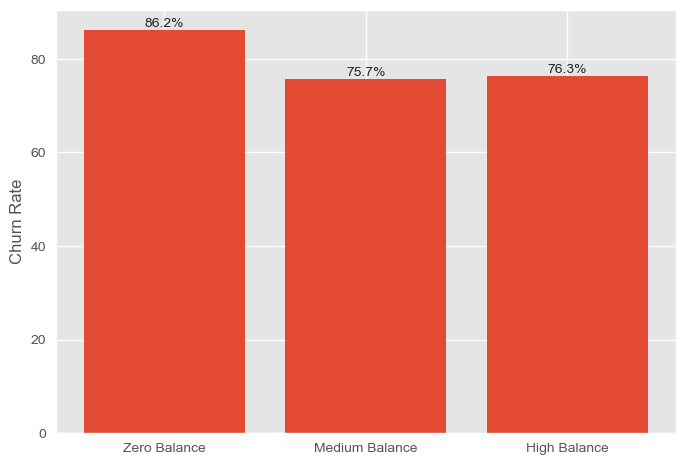

In [32]:
churn_rate = [c/t*100 for c, t in zip(Ex_Customers_b, Total_b)]

bars = plt.bar(Balance, churn_rate)
for bar, val in zip(bars, churn_rate):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.1f}%', ha='center', va='bottom')
plt.ylabel("Churn Rate")
plt.show()

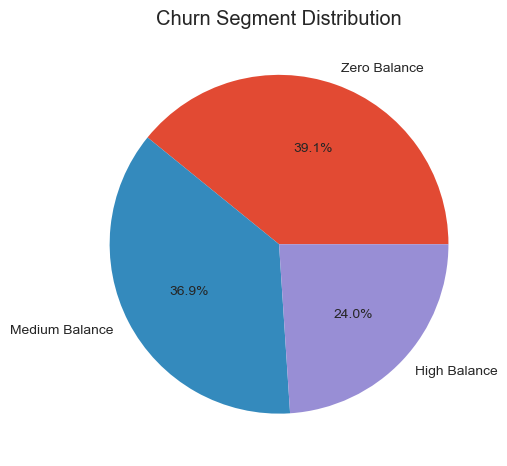

In [33]:
# Segment Wise Analysis
import matplotlib.pyplot as plt

labels = Balance 
sizes = Ex_Customers_b

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Churn Segment Distribution')

plt.show()

#### Majority of Our Churn Are 
<ul>Zero Balance at 39.1%</ul>
<ul>Second Majority is Medium Balance 36.9%</ul>
<ul>Minority is of High Balance 24%</ul>

# 2. Age Wise Churn Comparsion

In [67]:
below_30_Filter = df[(df["Age"]<30)]
above_30_to_45_Filter = df[(df["Age"]>30)&(df["Age"]<45)]
above_46_to_60_Filter = df[(df["Age"]>46)&(df["Age"]<60)]
above_60_Filter = df[(df["Age"]>60)]

In [73]:
Ret_below_30 = below_30_Filter[below_30_Filter["Exited"]==1]
Churn_below_30 = below_30_Filter[below_30_Filter["Exited"]==0]

Ret_above_30_to_45 = above_30_to_45_Filter[above_30_to_45_Filter["Exited"]==1]
Churn_above_30_to_45 = above_30_to_45_Filter[above_30_to_45_Filter["Exited"]==0]

Ret_above_46_to_60 = above_46_to_60_Filter[above_46_to_60_Filter["Exited"]==1]
Churn_above_46_to_60 = above_46_to_60_Filter[above_46_to_60_Filter["Exited"]==0]

Ret_below_60 = above_60_Filter[above_60_Filter["Exited"]==1]
Churn_below_60 = above_60_Filter[above_60_Filter["Exited"]==0]

In [74]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('ggplot')

# Zero Balance Variable
C_Zero=Zero_B[Zero_B["Exited"]==1]
Cex_Zero=Zero_B[Zero_B["Exited"]==0]

C_Medium=Medium_B[Medium_B["Exited"]==1]
Cex_Medium=Medium_B[Medium_B["Exited"]==0]

C_High=High_B[High_B["Exited"]==1]
Cex_High=High_B[High_B["Exited"]==0]



Age_C = [Ret_below_30.shape[0],Ret_above_30_to_45.shape[0],Ret_above_46_to_60.shape[0],Ret_below_60.shape[0]]
Age_Ex_C = [Ret_below_30.shape[0],Churn_above_30_to_45.shape[0],Churn_above_46_to_60.shape[0],Churn_below_60.shape[0]]
Age_Segement = ["Under 30", "From 30 to 45", "from 46 to 60", "Above 60"]
Total_Age_C=[Ret_below_30.shape[0]+Ret_below_30.shape[0],Ret_above_30_to_45.shape[0]+Churn_above_30_to_45.shape[0],Ret_above_46_to_60.shape[0]+Churn_above_46_to_60.shape[0],Ret_below_60.shape[0]+Churn_below_60.shape[0]]
   

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (3,) and arg 1 with shape (4,).

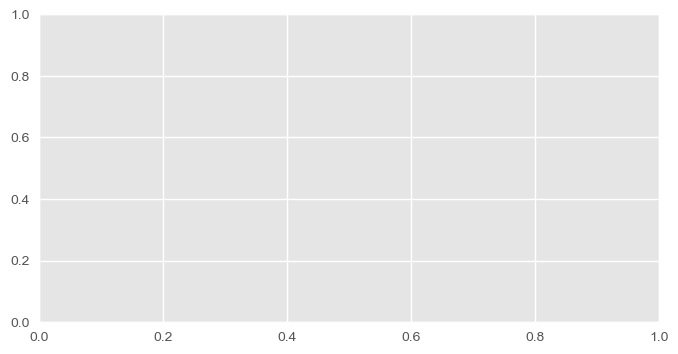

In [71]:
#Test Code
fig2, ax = plt.subplots(figsize=(8, 4))
bars_ret   = ax.bar(x - width/2, Age_C,    width, label='Retained', color='steelblue')
bars_churn = ax.bar(x + width/2, Age_Ex_C, width, label='Churned',  color='tomato')
ax.bar_label(bars_ret,   padding=3)
ax.bar_label(bars_churn, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(Age_Segment)
ax.set_ylabel("Count")
ax.set_title("Churn vs Retention by Age Segment")
ax.legend()
plt.tight_layout()
plt.show()

In [64]:
Retention_rate = [c/t*100 for c, t in zip(Age_C, Total_Age_C )]

bars = plt.bar(Age_Segment, Retention_rate)
for bar, val in zip(bars, Retention_rate):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.1f}%', ha='center', va='bottom')


plt.xlabel("Age Segments")
plt.ylabel("Retention rate in %")
plt.tight_layout()
plt.show()

NameError: name 'Age_Segment' is not defined

In [65]:

plt.style.use('seaborn-v0_8')
    
Churn_rate = [c/t*100 for c, t in zip(Age_Ex_C, Total_Age_C )]

bars = plt.bar(Age_Segment, Churn_rate)
for bar, val in zip(bars, Churn_rate):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.1f}%', ha='center', va='bottom')
    
plt.xlabel("Age Segments")
plt.ylabel("Churn Rate in %")

NameError: name 'Age_Segment' is not defined

In [66]:
# Segment Wise Analysis
import matplotlib.pyplot as plt

labels = Age_Segment
sizes = Age_Ex_C 

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Age Bracket wise Segment Distribution of churn Rate ')

plt.show()

NameError: name 'Age_Segment' is not defined

### More Than 85% of churn is coming from Two Age Brackets
<ul>1. 30-45 Years:    65.9%</ul>
<ul>2. Under 30 Years: 20.6%</ul>




# 3. Credit Score Wise Churn Comparison

In [41]:
# CREDIT SCORE == LOW
# Between 350 to 584
cd_low=df[(df["Credit Score"]<584)]
# CREDIT SCORE == MEDIUM
# Between 584 to 718
cd_medium=df[(df["Credit Score"]>584)&(df["Credit Score"]<718)]
# CREDIT SCORE == HIGH
# Between 718 to 850
cd_high=df[(df["Credit Score"]>718)]

In [42]:
cdl_C=cd_low[cd_low["Exited"]==1]
cdl_Cex=cd_low[cd_low["Exited"]==0]

cdm_C=cd_medium[cd_medium["Exited"]==1]
cdm_Cex=cd_medium[cd_medium["Exited"]==0]

cdh_C=cd_high[cd_high["Exited"]==1]
cdh_Cex=cd_high[cd_high["Exited"]==0]

In [43]:
Credit_Score=["High", "Medium", "Low"]
CS_Based_customer_ratio=[cdl_C.shape[0],cdm_C.shape[0],cdh_C.shape[0]]
CS_Based_ex_customer_ratio=[cdl_Cex.shape[0],cdm_Cex.shape[0],cdh_Cex.shape[0]]

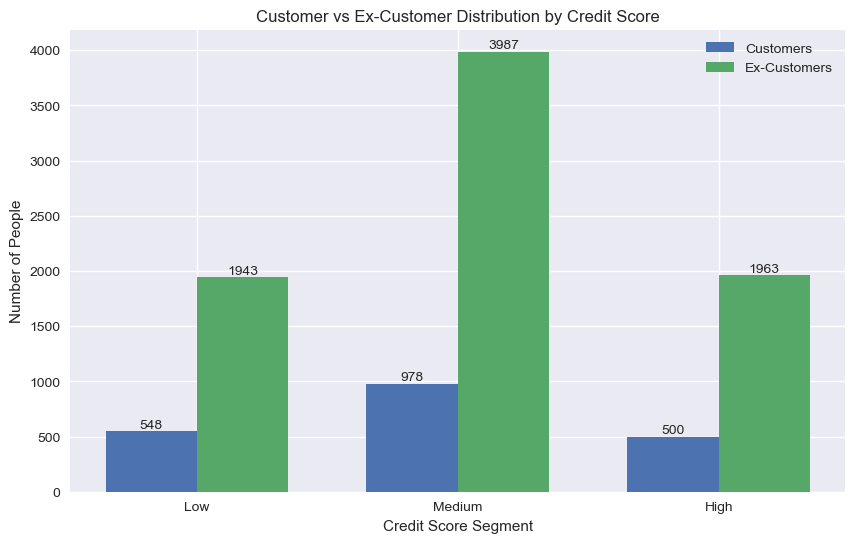

In [44]:
import numpy as np
import matplotlib.pyplot as plt

Credit_Score = ["Low", "Medium", "High"]

customer = [cdl_C.shape[0], cdm_C.shape[0], cdh_C.shape[0]]
ex_customer = [cdl_Cex.shape[0], cdm_Cex.shape[0], cdh_Cex.shape[0]]
total_asd=[cdl_C.shape[0]+cdl_Cex.shape[0],cdm_C.shape[0]+cdm_Cex.shape[0],cdh_C.shape[0]+cdh_Cex.shape[0]]

x = np.arange(len(Credit_Score))  # positions
width = 0.35  # bar width

plt.figure(figsize=(10,6))

# Bars
bars1 = plt.bar(x - width/2, customer, width, label='Customers')
bars2 = plt.bar(x + width/2, ex_customer, width, label='Ex-Customers')

# Labels
plt.xticks(x, Credit_Score)
plt.xlabel("Credit Score Segment")
plt.ylabel("Number of People")
plt.title("Customer vs Ex-Customer Distribution by Credit Score")

# Values on bars
for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{int(bar.get_height())}',
            ha='center', va='bottom'
        )

plt.legend()
plt.show()

In [45]:
# plt.style.use('seaborn-v0_8')
    
# Churn_rate = [c/t*100 for c, t in zip(ex_customer, total_asd )]

# bars = plt.bar(Credit_Score, Churn_rate)
# for bar, val in zip(bars, Churn_rate):
#     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
#              f'{val:.1f}%', ha='center', va='bottom')
    
# plt.xlabel("Credit Score Segments")
# plt.ylabel("Churn Rate in %")

In [46]:
# plt.style.use('seaborn-v0_8')
    
# Retention_rate= [c/t*100 for c, t in zip(customer, total_asd )]

# bars = plt.bar(Credit_Score, Retention_rate)
# for bar, val in zip(bars, Churn_rate):
#     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
#              f'{val:.1f}%', ha='center', va='bottom')
    
# plt.xlabel("Credit Score Segments")
# plt.ylabel("Retention rate in %")

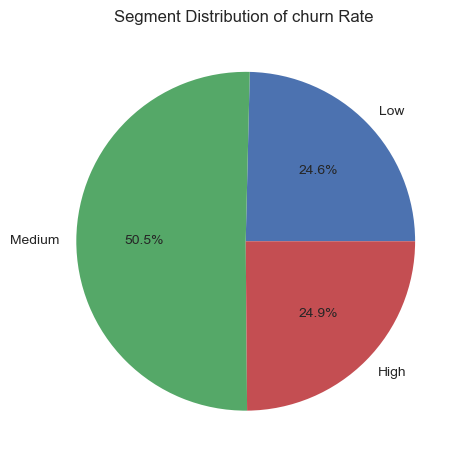

In [47]:
# Segment Wise Analysis
import matplotlib.pyplot as plt

labels = Credit_Score
sizes = ex_customer

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Segment Distribution of churn Rate ')

plt.show()

### Maximum Churn is from Medium Credit Score Bracket Which is 50.5%

# 4. Tenure Wise Churn Comaparison

In [48]:
# DataFrame which is Called out is fasbce
C_New_T= df[(df["Tenure"]<=3)&(df["Exited"]==1)]
Cex_New_T= df[(df["Tenure"]<=3)&(df["Exited"]==0)]

C_Mid_Term_T= df[(df["Tenure"]>3)&(df["Tenure"]<=7)&(df["Exited"]==1)]
Cex_Mid_Term_T= df[(df["Tenure"]>3)&(df["Tenure"]<=7)&(df["Exited"]==0)]

C_Mid_Term_T= df[(df["Tenure"]>7)&(df["Tenure"]<=10)&(df["Exited"]==1)]
Cex_Long_Term_T= df[(df["Tenure"]>7)&(df["Tenure"]<=10)&(df["Exited"]==0)]

Tenure = ["New", "Mid-Term", "Long-Term"]

C_te_N=[C_New_T.shape[0],C_Mid_Term_T.shape[0],C_Mid_Term_T.shape[0]]
Cex_te_N=[C_New_T.shape[0],C_Mid_Term_T.shape[0],Cex_Long_Term_T.shape[0]]
Total_te_N=[C_New_T.shape[0]+C_New_T.shape[0],C_Mid_Term_T.shape[0]+C_Mid_Term_T.shape[0],C_Mid_Term_T.shape[0]+Cex_Long_Term_T.shape[0]]



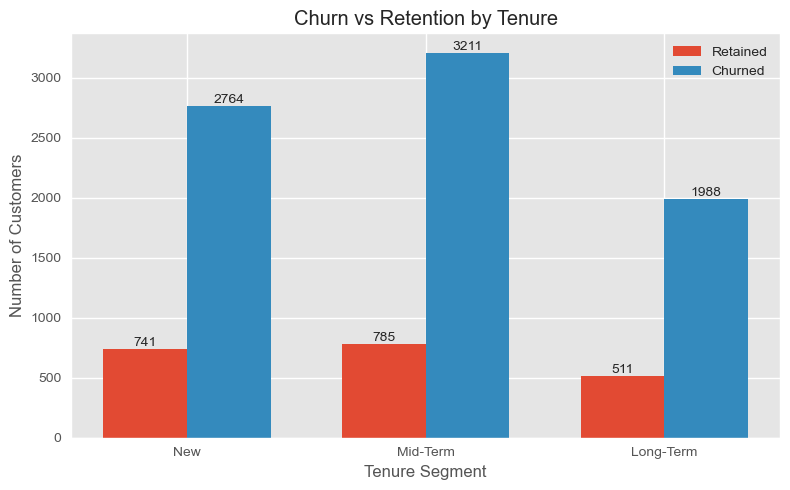

In [49]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

# -------------------------------
# 1. Define Segments Properly
# -------------------------------
C_New_T = df[(df["Tenure"] <= 3) & (df["Exited"] == 0)]
Cex_New_T = df[(df["Tenure"] <= 3) & (df["Exited"] == 1)]

C_Mid_Term_T = df[(df["Tenure"] > 3) & (df["Tenure"] <= 7) & (df["Exited"] == 0)]
Cex_Mid_Term_T = df[(df["Tenure"] > 3) & (df["Tenure"] <= 7) & (df["Exited"] == 1)]

C_Long_Term_T = df[(df["Tenure"] > 7) & (df["Tenure"] <= 10) & (df["Exited"] == 0)]
Cex_Long_Term_T = df[(df["Tenure"] > 7) & (df["Tenure"] <= 10) & (df["Exited"] == 1)]

Tenure = ["New", "Mid-Term", "Long-Term"]

# -------------------------------
# 2. Counts
# -------------------------------
churned = [
    C_New_T.shape[0],
    C_Mid_Term_T.shape[0],
    C_Long_Term_T.shape[0]
]

retained = [
    Cex_New_T.shape[0],
    Cex_Mid_Term_T.shape[0],
    Cex_Long_Term_T.shape[0]
]

# -------------------------------
# 3. Proper Visualization (Grouped)
# -------------------------------
x = np.arange(len(Tenure))
width = 0.35

plt.figure(figsize=(8,5))

bars1 = plt.bar(x - width/2, retained, width, label="Retained")
bars2 = plt.bar(x + width/2, churned, width, label="Churned")

# Labels
for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{int(bar.get_height())}',
            ha='center', va='bottom'
        )

plt.xticks(x, Tenure)
plt.xlabel("Tenure Segment")
plt.ylabel("Number of Customers")
plt.title("Churn vs Retention by Tenure")
plt.legend()

plt.tight_layout()
plt.show()

In [50]:
# plt.style.use('seaborn-v0_8')
    
# Retention_rate= [c/t*100 for c, t in zip(C_te_N, Total_te_N)]

# bars = plt.bar(Tenure, Retention_rate)
# for bar, val in zip(bars, Retention_rate):
#     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
#              f'{val:.1f}%', ha='center', va='bottom')
    
# plt.xlabel("Various Tenure Segmentation")
# plt.ylabel("Retention rate in %")

Text(0, 0.5, 'Churn rate in %')

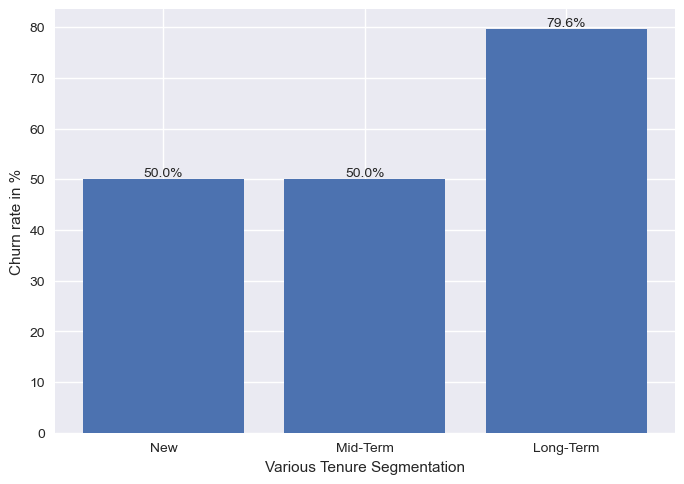

In [51]:
plt.style.use('seaborn-v0_8')
    
Churn_rate= [a/b*100 for a, b in zip(Cex_te_N, Total_te_N)]

bars = plt.bar(Tenure, Churn_rate)
for bar, val in zip(bars, Churn_rate):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.1f}%', ha='center', va='bottom')
    
plt.xlabel("Various Tenure Segmentation")
plt.ylabel("Churn rate in %")

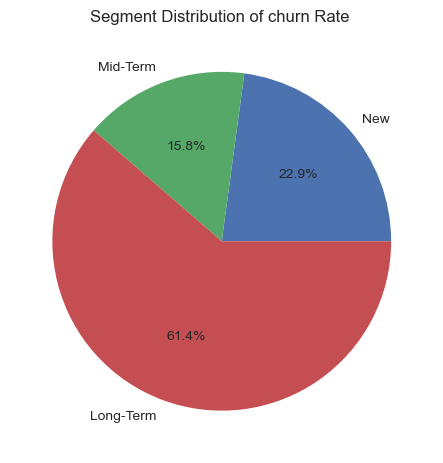

In [52]:
# Segment Wise Analysis
import matplotlib.pyplot as plt

labels = Tenure
sizes = Cex_te_N

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Segment Distribution of churn Rate ')

plt.show()

### Maximum Churn Rate  is coming from long-term customers Which is 61.4% 

